# 1: Upload all metric CSV files

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import os

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

print("Uploaded files:")
for f in uploaded_files:
    print(f)

Saving byt5_small_final_metrics.csv to byt5_small_final_metrics.csv
Saving mt5_base_final_metrics.csv to mt5_base_final_metrics.csv
Saving bloom_560m_final_metrics.csv to bloom_560m_final_metrics.csv
Saving gemini_final_metrics (1).csv to gemini_final_metrics (1).csv
Saving mbart50_final_metrics (1).csv to mbart50_final_metrics (1).csv
Saving banglagpt_final_metrics.csv to banglagpt_final_metrics.csv
Saving banglabert_encoder_decoder_final_metrics.csv to banglabert_encoder_decoder_final_metrics.csv
Saving mt5_small_final_metrics.csv to mt5_small_final_metrics.csv
Saving banglat5_final_metrics (1).csv to banglat5_final_metrics (1).csv
Uploaded files:
byt5_small_final_metrics.csv
mt5_base_final_metrics.csv
bloom_560m_final_metrics.csv
gemini_final_metrics (1).csv
mbart50_final_metrics (1).csv
banglagpt_final_metrics.csv
banglabert_encoder_decoder_final_metrics.csv
mt5_small_final_metrics.csv
banglat5_final_metrics (1).csv


# 2: Read and merge all metric files

In [ ]:
metric_files = [
    file for file in uploaded_files
    if file.endswith(".csv")
]

all_metrics = []

for file in metric_files:
    try:
        df = pd.read_csv(file)

        if "Model" not in df.columns:
            print(f"Skipping {file}: No Model column found")
            continue

        all_metrics.append(df)
        print(f"Loaded: {file}")

    except Exception as e:
        print(f"Error reading {file}: {e}")

comparison_df = pd.concat(all_metrics, ignore_index=True)

comparison_df

Loaded: byt5_small_final_metrics.csv
Loaded: mt5_base_final_metrics.csv
Loaded: bloom_560m_final_metrics.csv
Loaded: gemini_final_metrics (1).csv
Loaded: mbart50_final_metrics (1).csv
Loaded: banglagpt_final_metrics.csv
Loaded: banglabert_encoder_decoder_final_metrics.csv
Loaded: mt5_small_final_metrics.csv
Loaded: banglat5_final_metrics (1).csv


,Model,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore Precision,BERTScore Recall,...,Distinct-1,Distinct-2,Novelty,Average Max Train Similarity,Near Copy Rate,Abuse-word rate,Abusive outputs,METEOR,Average Generated Length,Empty Output Rate
0,ByT5-small,0.101531,0.046100,0.025869,0.018325,0.124107,0.024702,0.119689,0.873604,0.861987,...,0.096335,0.192751,0.563936,0.436064,0.009934,0.016556,5,0.075111,8.764901,0.0
1,mT5-base,0.055010,0.029566,0.018053,0.014267,0.104015,0.029187,0.102356,0.878074,0.850785,...,0.089329,0.166179,0.535307,0.464693,0.000000,0.043046,13,0.058247,5.523179,0.0
2,BLOOM-560M,0.105805,0.050280,0.030466,0.021810,0.121389,0.027951,0.113724,0.871477,0.864935,...,0.172391,0.479167,0.520136,0.479864,0.076159,0.006623,2,0.079885,10.218543,0.0
3,Gemini,0.085273,0.036553,0.021503,0.015600,0.098735,0.017734,0.096806,0.867774,0.857281,...,0.010172,0.013731,0.530913,0.469087,0.000000,0.000000,0,0.059472,9.440397,0.0
4,mBART50,0.088673,0.038872,0.024725,0.017803,0.104853,0.020270,0.099713,0.868968,0.863960,...,0.096661,0.206056,0.456221,0.543779,0.228477,0.023179,7,0.063650,9.420530,0.0
5,BanglaGPT,0.060437,0.023574,0.014877,0.011575,0.072314,0.009530,0.068751,0.855089,0.854670,...,0.274743,0.614235,0.711403,0.288597,0.000000,0.003311,1,0.043391,10.304636,0.0
6,BanglaBERT,0.073304,0.031308,0.018063,0.013269,0.085685,0.014770,0.082299,0.863495,0.856244,...,0.136508,0.423104,0.614651,0.385349,0.006623,0.026490,8,0.053921,10.430464,0.0
7,mT5-small,0.064905,0.032156,0.021155,0.016290,0.120516,0.028748,0.119884,0.885150,0.853186,...,0.040140,0.095977,0.521043,0.478957,0.009934,0.000000,0,0.064926,5.692053,0.0
8,Bangla-T5,0.102941,0.051483,0.029296,0.021610,0.142967,0.037446,0.137582,0.880080,0.851817,...,0.080295,0.153347,0.539139,0.460861,0.000000,0.009934,3,0.086759,7.629139,0.0


# 3: Standardize column order

In [ ]:
preferred_columns = [
    "Model",

    "BLEU-1",
    "BLEU-2",
    "BLEU-3",
    "BLEU-4",

    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",

    "BERTScore Precision",
    "BERTScore Recall",
    "BERTScore F1",

    "Diversity",
    "Distinct-1",
    "Distinct-2",

    "Novelty",
    "Average Max Train Similarity",
    "Near Copy Rate",

    "Exact Copy Rate",

    "Abuse-word rate",
    "Abusive outputs",

    "METEOR",

    "Average Generated Length",
    "Empty Output Rate"
]

existing_columns = [col for col in preferred_columns if col in comparison_df.columns]
extra_columns = [col for col in comparison_df.columns if col not in existing_columns]

comparison_df = comparison_df[existing_columns + extra_columns]

comparison_df

,Model,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore Precision,BERTScore Recall,...,Distinct-1,Distinct-2,Novelty,Average Max Train Similarity,Near Copy Rate,Abuse-word rate,Abusive outputs,METEOR,Average Generated Length,Empty Output Rate
0,ByT5-small,0.101531,0.046100,0.025869,0.018325,0.124107,0.024702,0.119689,0.873604,0.861987,...,0.096335,0.192751,0.563936,0.436064,0.009934,0.016556,5,0.075111,8.764901,0.0
1,mT5-base,0.055010,0.029566,0.018053,0.014267,0.104015,0.029187,0.102356,0.878074,0.850785,...,0.089329,0.166179,0.535307,0.464693,0.000000,0.043046,13,0.058247,5.523179,0.0
2,BLOOM-560M,0.105805,0.050280,0.030466,0.021810,0.121389,0.027951,0.113724,0.871477,0.864935,...,0.172391,0.479167,0.520136,0.479864,0.076159,0.006623,2,0.079885,10.218543,0.0
3,Gemini,0.085273,0.036553,0.021503,0.015600,0.098735,0.017734,0.096806,0.867774,0.857281,...,0.010172,0.013731,0.530913,0.469087,0.000000,0.000000,0,0.059472,9.440397,0.0
4,mBART50,0.088673,0.038872,0.024725,0.017803,0.104853,0.020270,0.099713,0.868968,0.863960,...,0.096661,0.206056,0.456221,0.543779,0.228477,0.023179,7,0.063650,9.420530,0.0
5,BanglaGPT,0.060437,0.023574,0.014877,0.011575,0.072314,0.009530,0.068751,0.855089,0.854670,...,0.274743,0.614235,0.711403,0.288597,0.000000,0.003311,1,0.043391,10.304636,0.0
6,BanglaBERT,0.073304,0.031308,0.018063,0.013269,0.085685,0.014770,0.082299,0.863495,0.856244,...,0.136508,0.423104,0.614651,0.385349,0.006623,0.026490,8,0.053921,10.430464,0.0
7,mT5-small,0.064905,0.032156,0.021155,0.016290,0.120516,0.028748,0.119884,0.885150,0.853186,...,0.040140,0.095977,0.521043,0.478957,0.009934,0.000000,0,0.064926,5.692053,0.0
8,Bangla-T5,0.102941,0.051483,0.029296,0.021610,0.142967,0.037446,0.137582,0.880080,0.851817,...,0.080295,0.153347,0.539139,0.460861,0.000000,0.009934,3,0.086759,7.629139,0.0


# 4: Round numeric values

In [ ]:
comparison_rounded_df = comparison_df.copy()

numeric_cols = comparison_rounded_df.select_dtypes(include=[np.number]).columns

comparison_rounded_df[numeric_cols] = comparison_rounded_df[numeric_cols].round(4)

comparison_rounded_df

,Model,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore Precision,BERTScore Recall,...,Distinct-1,Distinct-2,Novelty,Average Max Train Similarity,Near Copy Rate,Abuse-word rate,Abusive outputs,METEOR,Average Generated Length,Empty Output Rate
0,ByT5-small,0.1015,0.0461,0.0259,0.0183,0.1241,0.0247,0.1197,0.8736,0.8620,...,0.0963,0.1928,0.5639,0.4361,0.0099,0.0166,5,0.0751,8.7649,0.0
1,mT5-base,0.0550,0.0296,0.0181,0.0143,0.1040,0.0292,0.1024,0.8781,0.8508,...,0.0893,0.1662,0.5353,0.4647,0.0000,0.0430,13,0.0582,5.5232,0.0
2,BLOOM-560M,0.1058,0.0503,0.0305,0.0218,0.1214,0.0280,0.1137,0.8715,0.8649,...,0.1724,0.4792,0.5201,0.4799,0.0762,0.0066,2,0.0799,10.2185,0.0
3,Gemini,0.0853,0.0366,0.0215,0.0156,0.0987,0.0177,0.0968,0.8678,0.8573,...,0.0102,0.0137,0.5309,0.4691,0.0000,0.0000,0,0.0595,9.4404,0.0
4,mBART50,0.0887,0.0389,0.0247,0.0178,0.1049,0.0203,0.0997,0.8690,0.8640,...,0.0967,0.2061,0.4562,0.5438,0.2285,0.0232,7,0.0637,9.4205,0.0
5,BanglaGPT,0.0604,0.0236,0.0149,0.0116,0.0723,0.0095,0.0688,0.8551,0.8547,...,0.2747,0.6142,0.7114,0.2886,0.0000,0.0033,1,0.0434,10.3046,0.0
6,BanglaBERT,0.0733,0.0313,0.0181,0.0133,0.0857,0.0148,0.0823,0.8635,0.8562,...,0.1365,0.4231,0.6147,0.3853,0.0066,0.0265,8,0.0539,10.4305,0.0
7,mT5-small,0.0649,0.0322,0.0212,0.0163,0.1205,0.0287,0.1199,0.8851,0.8532,...,0.0401,0.0960,0.5210,0.4790,0.0099,0.0000,0,0.0649,5.6921,0.0
8,Bangla-T5,0.1029,0.0515,0.0293,0.0216,0.1430,0.0374,0.1376,0.8801,0.8518,...,0.0803,0.1533,0.5391,0.4609,0.0000,0.0099,3,0.0868,7.6291,0.0


# 6: Save final comparison CSV

In [ ]:
final_csv = "/content/all_model_comparison.csv"

comparison_rounded_df.to_csv(final_csv, index=False, encoding="utf-8-sig")

print("Saved:", final_csv)

files.download(final_csv)

Saved: /content/all_model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 7: Save final comparison Excel file

In [ ]:
final_excel = "/content/all_model_comparison.xlsx"

comparison_rounded_df.to_excel(final_excel, index=False)

print("Saved:", final_excel)

files.download(final_excel)

Saved: /content/all_model_comparison.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 8: Create ranking by important metrics

In [ ]:
ranking_df = comparison_rounded_df.copy()

higher_better = [
    "BLEU-1",
    "BLEU-2",
    "BLEU-3",
    "BLEU-4",
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "BERTScore F1",
    "Diversity",
    "Novelty",
    "METEOR"
]

lower_better = [
    "Abuse-word rate",
    "Empty Output Rate"
]

available_higher = [col for col in higher_better if col in ranking_df.columns]
available_lower = [col for col in lower_better if col in ranking_df.columns]

for col in available_higher:
    min_val = ranking_df[col].min()
    max_val = ranking_df[col].max()

    if max_val - min_val == 0:
        ranking_df[col + "_norm"] = 0
    else:
        ranking_df[col + "_norm"] = (ranking_df[col] - min_val) / (max_val - min_val)

for col in available_lower:
    min_val = ranking_df[col].min()
    max_val = ranking_df[col].max()

    if max_val - min_val == 0:
        ranking_df[col + "_norm"] = 0
    else:
        ranking_df[col + "_norm"] = 1 - ((ranking_df[col] - min_val) / (max_val - min_val))

norm_cols = [col for col in ranking_df.columns if col.endswith("_norm")]

ranking_df["Overall Score"] = ranking_df[norm_cols].mean(axis=1)

ranking_df = ranking_df.sort_values(
    "Overall Score",
    ascending=False
).reset_index(drop=True)

ranking_df[["Model", "Overall Score"] + available_higher + available_lower]

,Model,Overall Score,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1,Diversity,Novelty,METEOR,Abuse-word rate,Empty Output Rate
0,Bangla-T5,0.765749,0.1029,0.0515,0.0293,0.0216,0.1430,0.0374,0.1376,0.8656,0.1168,0.5391,0.0868,0.0099,0.0
1,BLOOM-560M,0.736972,0.1058,0.0503,0.0305,0.0218,0.1214,0.0280,0.1137,0.8681,0.3258,0.5201,0.0799,0.0066,0.0
2,ByT5-small,0.622714,0.1015,0.0461,0.0259,0.0183,0.1241,0.0247,0.1197,0.8677,0.1445,0.5639,0.0751,0.0166,0.0
3,mT5-small,0.489187,0.0649,0.0322,0.0212,0.0163,0.1205,0.0287,0.1199,0.8688,0.0681,0.5210,0.0649,0.0000,0.0
4,mBART50,0.448018,0.0887,0.0389,0.0247,0.0178,0.1049,0.0203,0.0997,0.8664,0.1514,0.4562,0.0637,0.0232,0.0
5,Gemini,0.396805,0.0853,0.0366,0.0215,0.0156,0.0987,0.0177,0.0968,0.8624,0.0120,0.5309,0.0595,0.0000,0.0
6,mT5-base,0.300825,0.0550,0.0296,0.0181,0.0143,0.1040,0.0292,0.1024,0.8641,0.1278,0.5353,0.0582,0.0430,0.0
7,BanglaBERT,0.292831,0.0733,0.0313,0.0181,0.0133,0.0857,0.0148,0.0823,0.8598,0.2798,0.6147,0.0539,0.0265,0.0
8,BanglaGPT,0.233043,0.0604,0.0236,0.0149,0.0116,0.0723,0.0095,0.0688,0.8548,0.4445,0.7114,0.0434,0.0033,0.0


# 9: Save ranked comparison

In [ ]:
ranking_csv = "/content/all_model_ranking.csv"
ranking_excel = "/content/all_model_ranking.xlsx"

ranking_df.to_csv(ranking_csv, index=False, encoding="utf-8-sig")
ranking_df.to_excel(ranking_excel, index=False)

files.download(ranking_csv)
files.download(ranking_excel)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 10: Bar chart for BERTScore F1

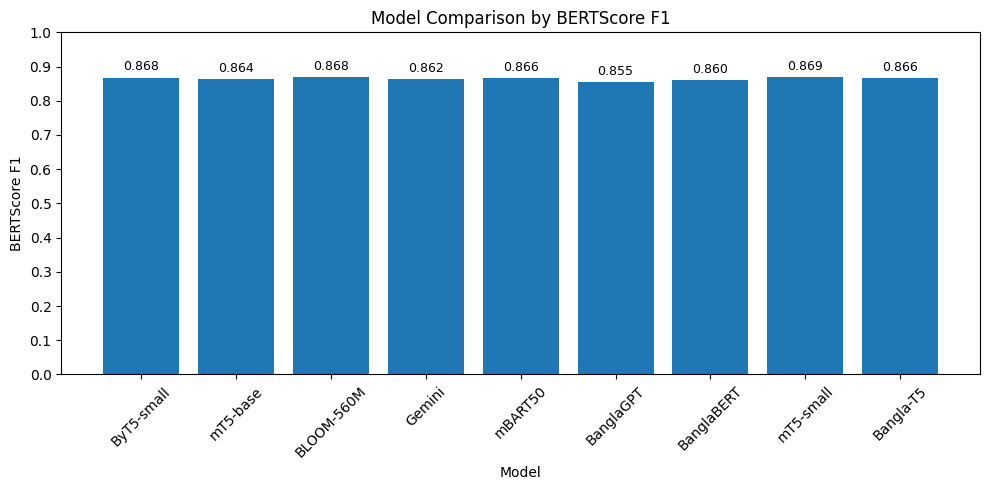

In [ ]:
import matplotlib.pyplot as plt

if "BERTScore F1" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["BERTScore F1"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("BERTScore F1")
    plt.title("Model Comparison by BERTScore F1")
    plt.ylim(0, 1.0)  # Set Y-axis range from 0 to 1.0
    plt.yticks([i / 10 for i in range(11)])  # Show intervals of 0.1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BERTScore F1 column not found.")

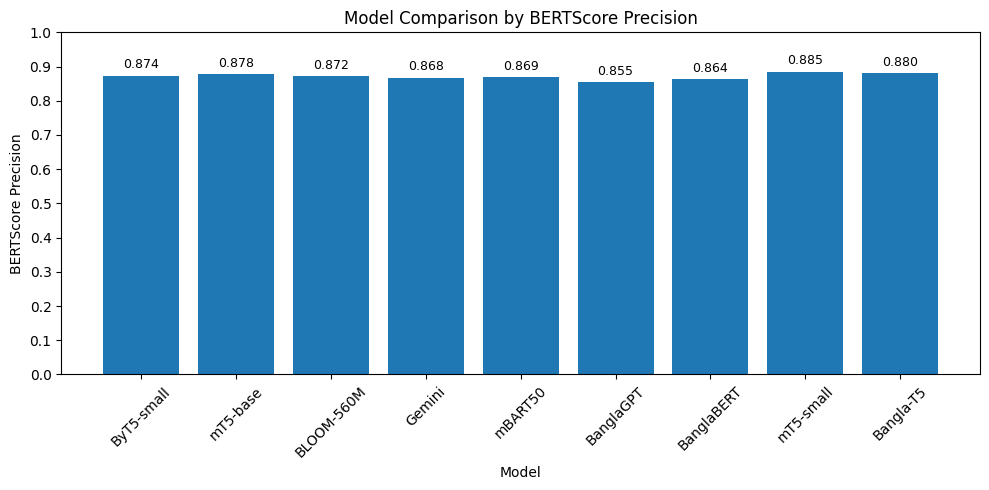

In [ ]:
import matplotlib.pyplot as plt

if "BERTScore Precision" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["BERTScore Precision"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("BERTScore Precision")
    plt.title("Model Comparison by BERTScore Precision")
    plt.ylim(0, 1.0)  # Set Y-axis range from 0 to 1.0
    plt.yticks([i / 10 for i in range(11)])  # Show intervals of 0.1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BERTScore Precision column not found.")

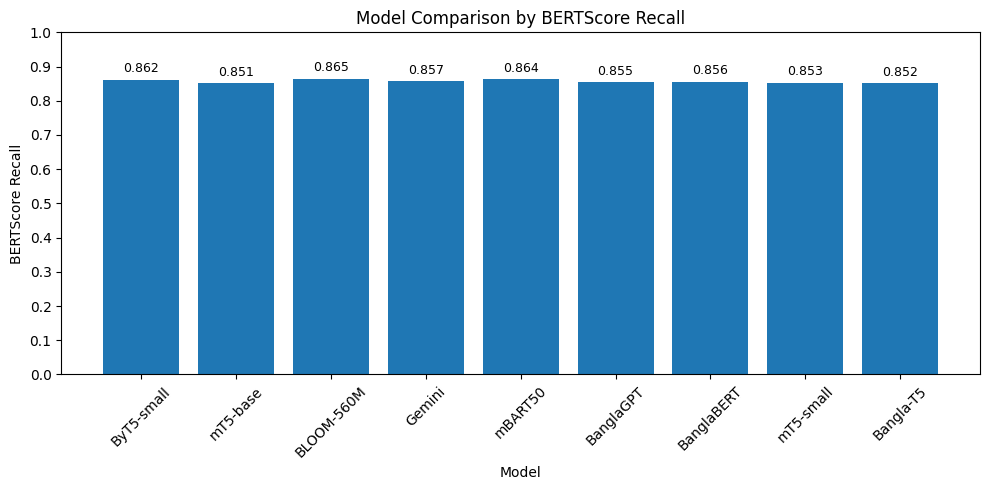

In [ ]:
import matplotlib.pyplot as plt

if "BERTScore Recall" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["BERTScore Recall"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("BERTScore Recall")
    plt.title("Model Comparison by BERTScore Recall")
    plt.ylim(0, 1.0)  # Set Y-axis range from 0 to 1.0
    plt.yticks([i / 10 for i in range(11)])  # Show intervals of 0.1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BERTScore Recall column not found.")

# 11: Bar chart for BLEU-4

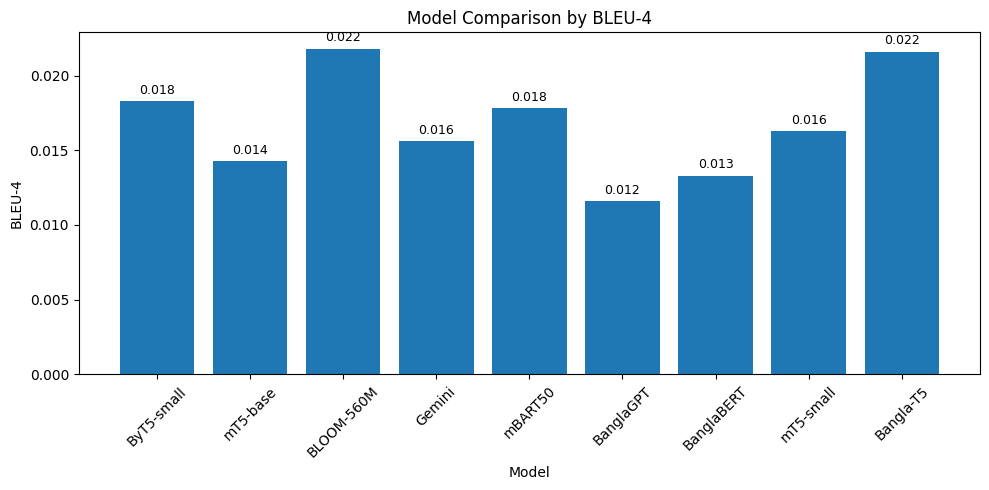

In [ ]:
if "BLEU-4" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["BLEU-4"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("BLEU-4")
    plt.title("Model Comparison by BLEU-4")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BLEU-4 column not found.")

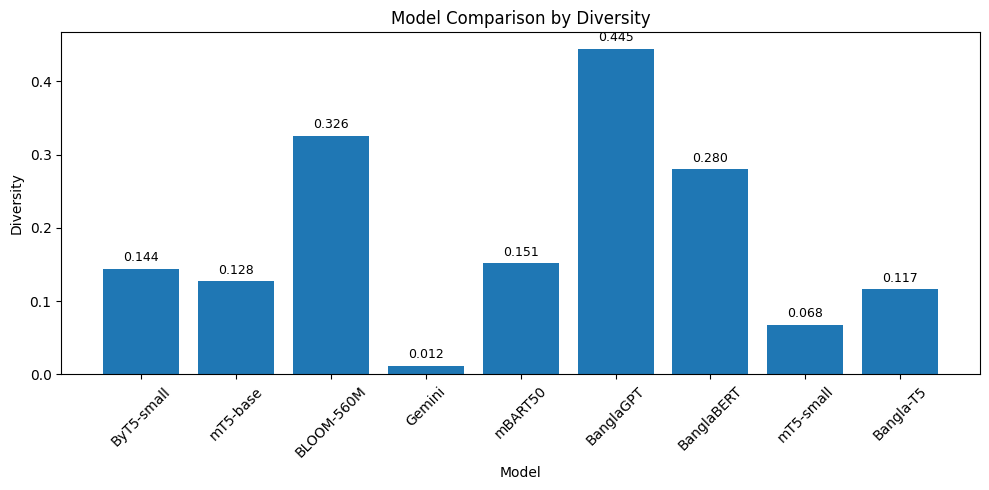

In [ ]:
if "Diversity" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["Diversity"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Diversity")
    plt.title("Model Comparison by Diversity")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Diversity column not found.")

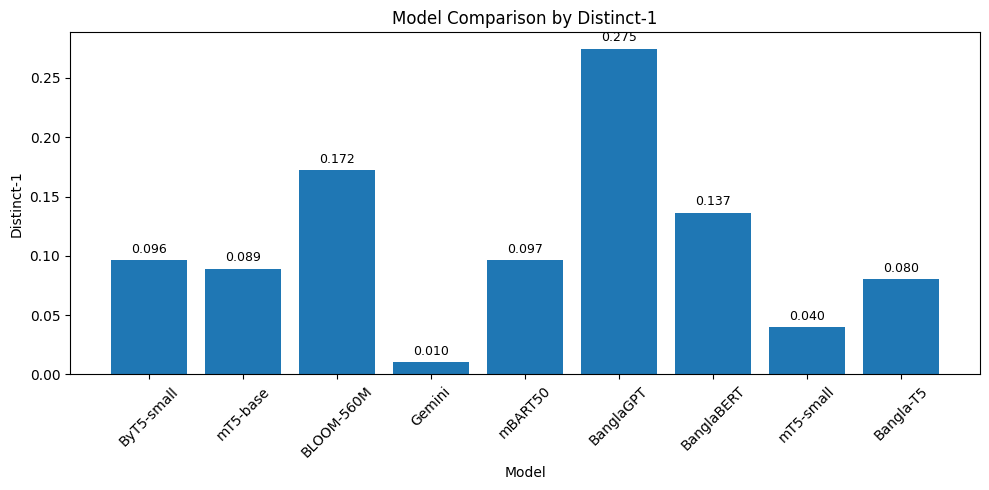

In [ ]:
if "Distinct-1" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["Distinct-1"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Distinct-1")
    plt.title("Model Comparison by Distinct-1")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Distinct-1 column not found.")

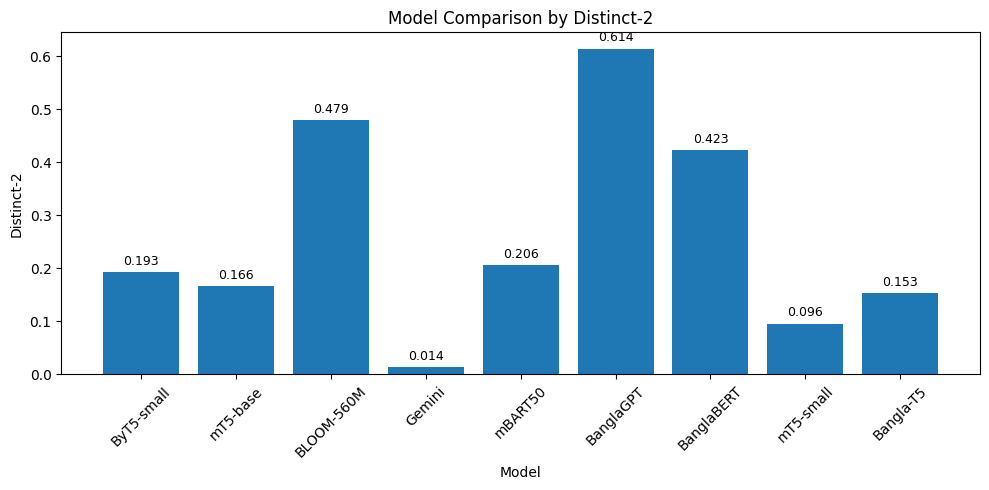

In [ ]:
if "Distinct-2" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["Distinct-2"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Distinct-2")
    plt.title("Model Comparison by Distinct-2")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Distinct-2 column not found.")

# 12: Bar chart for Abuse-word rate

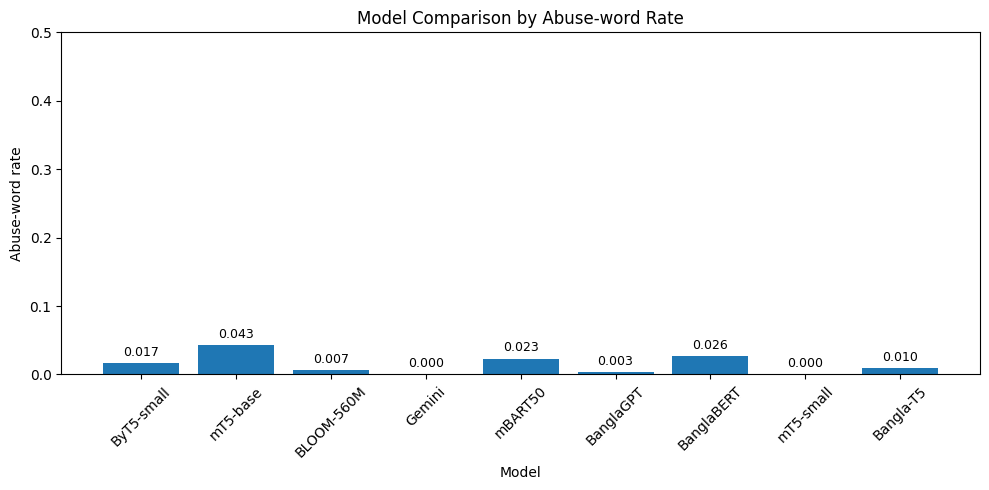

In [ ]:
if "Abuse-word rate" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["Abuse-word rate"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Abuse-word rate")
    plt.title("Model Comparison by Abuse-word Rate")
    plt.ylim(0, 0.5)  # Set Y-axis range from 0 to 1.0
    plt.yticks([i / 10 for i in range(6)])  # Show intervals of 0.1
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Abuse-word rate column not found.")

# 13: Bar chart for Overall Score

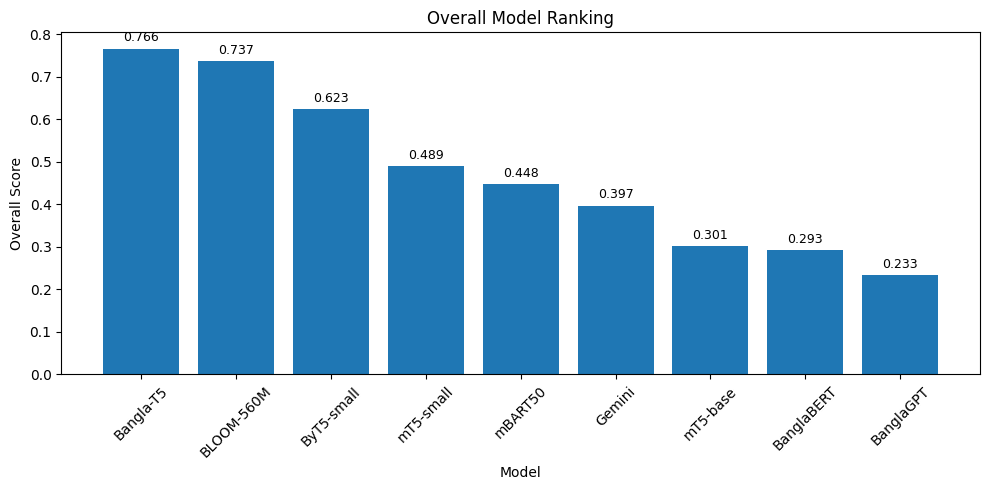

In [ ]:
if "Overall Score" in ranking_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(ranking_df["Model"].astype(str), ranking_df["Overall Score"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Overall Score")
    plt.title("Overall Model Ranking")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Overall Score column not found.")

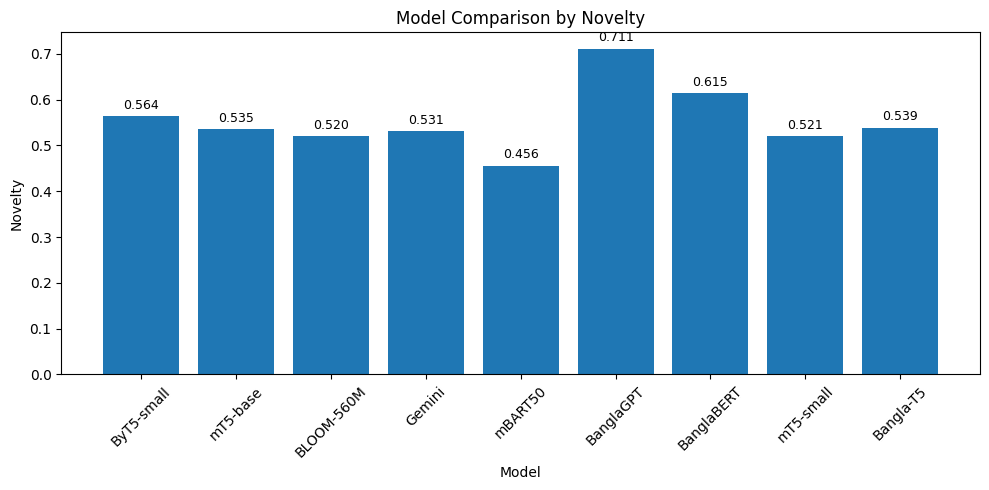

In [ ]:
if "Novelty" in comparison_rounded_df.columns:
    plt.figure(figsize=(10, 5))
    bars = plt.bar(comparison_rounded_df["Model"].astype(str), comparison_rounded_df["Novelty"])
    plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)  # show value on each bar
    plt.xlabel("Model")
    plt.ylabel("Novelty")
    plt.title("Model Comparison by Novelty")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Novelty column not found.")